iteration 23 results |k={K}
Log Likelihood: -723119.72
silhoutte: 0.158
cluster profile(means,original scale) - Iteration 23 GaussianMixture(RobustScaler) tied, labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
78169,32.17815253374793,1.24,20.854131168658782,26.78367584193336,0.334,0.22466621710436746,0.5362619660417434
3234,191.9263572760252,3.707,22.96134127054808,58.01580703182102,0.287,0.31716908065326205,0.5801660673810078
19879,36.50751784221308,1.289,21.859065633843137,29.745395771810045,0.31,0.5211754466105074,0.5503845527270053
6718,101.42880393207942,1.0,21.972067630076673,101.42880393207942,0.297,0.2919086010484788,0.5946050769688213


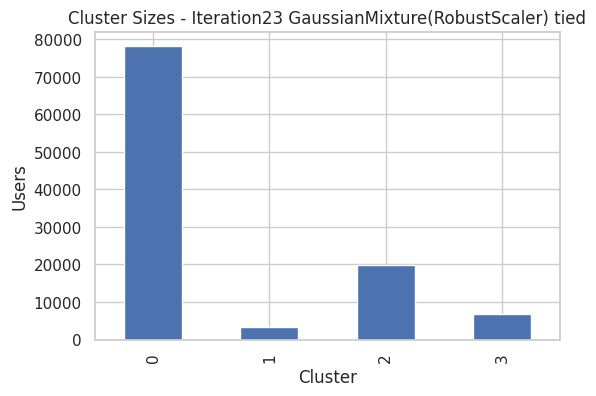

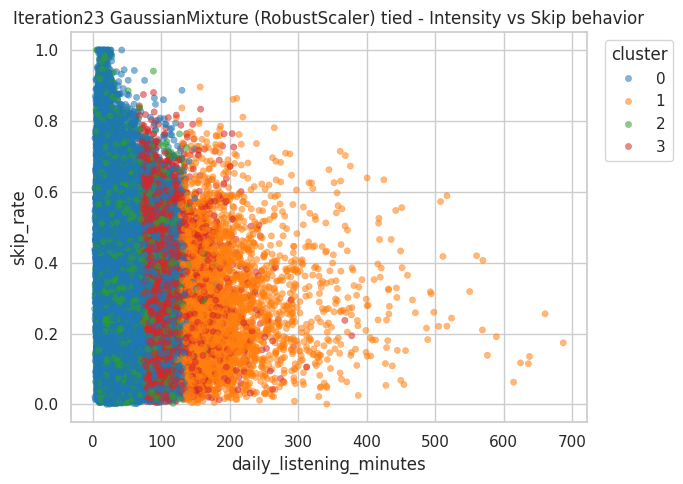

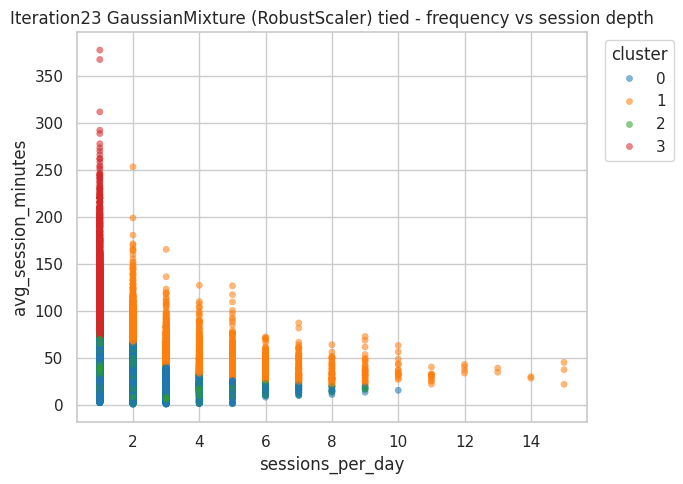

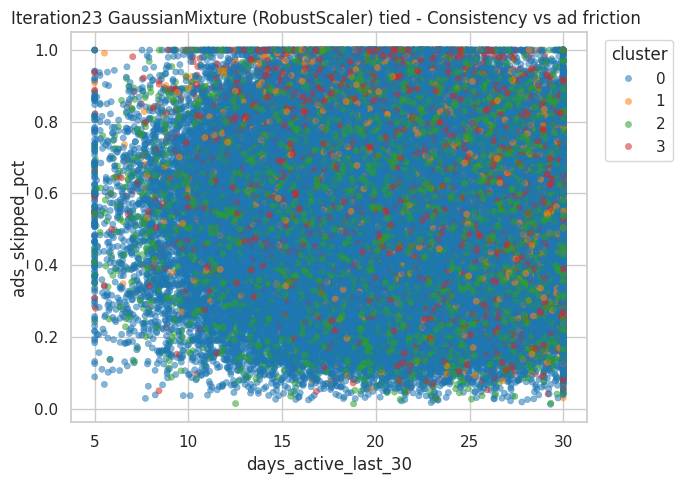

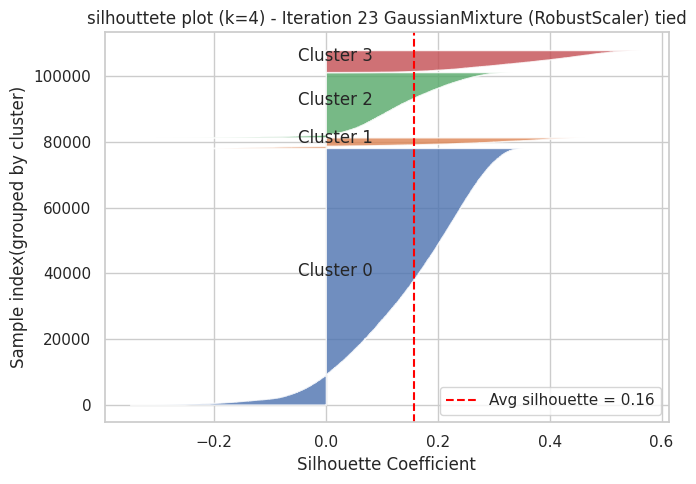

In [0]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score , silhouette_samples

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",
    "sessions_per_day",
    "days_active_last_30",
    "avg_session_minutes",
    "skip_rate",
    "liked_songs_pct",
    "ads_skipped_pct",
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

K = 4

X23 = base[CLUSTER_FEATURES_V1].copy()
Robust = RobustScaler()
X23_Robust = Robust.fit_transform(X23)

X23 = pd.DataFrame(
    X23_Robust,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

gmm23 = GaussianMixture(
    n_components=K,
    random_state=42,
    covariance_type="tied",
    n_init=5,
    max_iter=200
)

labels23 = gmm23.fit_predict(X23)

log_likelihood23 = gmm23.score(X23) * len(X23)
sil_avg_23 = silhouette_score(X23, labels23)

base_iter23 = base.copy()
base_iter23["cluster"] = labels23

print("iteration 23 results |k={K}")
print("Log Likelihood:", round(log_likelihood23, 2))
print("silhoutte:", round(sil_avg_23, 3))

sizes23 = base_iter23["cluster"].value_counts().sort_index()
means23 = (
    base_iter23
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile23 = means23.copy()
profile23.insert(0, "cluster_size", sizes23)

print("cluster profile(means,original scale) - Iteration 23 GaussianMixture(RobustScaler) tied, labels):")
display(profile23)

plt.figure(figsize=(6,4))
base_iter23["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration23 GaussianMixture(RobustScaler) tied")
plt.xlabel("Cluster")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter23,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration23 GaussianMixture (RobustScaler) tied - Intensity vs Skip behavior")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter23,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration23 GaussianMixture (RobustScaler) tied - frequency vs session depth")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter23,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration23 GaussianMixture (RobustScaler) tied - Consistency vs ad friction ")
plt.legend(title="cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

sil_values_23 = silhouette_samples(X23, labels23)

plt.figure(figsize=(7,5))
y_lower = 0

vals0 = sil_values_23[labels23 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

vals1 = sil_values_23[labels23 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

vals2 = sil_values_23[labels23 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

vals3 = sil_values_23[labels23 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sil_avg_23,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sil_avg_23:.2f}"
)

plt.title("silhouttete plot (k=4) - Iteration 23 GaussianMixture (RobustScaler) tied")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()
